# Member 4 Work Summary — Arham Jamshaid
As Member 4, my deliverables for Milestone 1 cover the full validation-and-visualisation layer that consumes the latest `features.csv`-driven FCM outputs and prepares diagnostics for later MPI scaling. This notebook documents and automates the following responsibilities:
- Detect every `membership_*.csv`/`centroids_*.csv` pair generated from the real feature matrix and keep the analysis rerunnable when new data arrives.
- Recreate the domain (ICD-style) cohorts, compute hard assignments, and report confusion matrices, purity, and adjusted Rand index for each initialization strategy.
- Visualize membership behaviour through sampled heatmaps and dominant-membership histograms to spot mode collapse or poorly separated clusters early.
- Surface representative documents per cluster (highest memberships) and inspect centroid top features to narrate the clinical themes behind each group.
- Capture timing/config hooks so Member 5 can plug MPI/parallel experiments without rewriting the analytics layer.
This summary ensures every reader knows what Arham Jamshaid (Member 4) owns before diving into the code below.

## How to use this notebook
1. Build + run `./fcm features.csv <N> <F> <C>` (or the appropriate CLI args) to regenerate the membership and centroid CSVs from the real feature matrix.
2. If the CSVs live in a different folder, update `BASE_DIR` below.
3. **Run all cells** — every plot/table refreshes from disk, so no manual edits are required when new data arrives.

Deliverables covered here:
- Membership distribution visualizations (heatmaps + histograms).
- Cohort comparison against domain labels (purity, confusion matrices, ARI).
- Representative documents per cluster (highest soft memberships).
- Centroid feature inspection to describe clinical concepts per cluster.
- Timing hooks and configuration points for future MPI experiments.

In [19]:
# Core scientific Python stack (kept in one cell for easy reruns)
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [20]:

# Locate membership / centroid files automatically so reruns work for any dataset
BASE_DIR = Path(".").resolve()  # change me if notebook is moved elsewhere
membership_paths = sorted(BASE_DIR.glob("membership_*.csv"))
if not membership_paths:
    raise FileNotFoundError("No membership_*.csv files were found. Run ./fcm first.")

STRATEGIES = {}
for m_path in membership_paths:
    suffix = m_path.stem.split("_", 1)[1]
    c_path = BASE_DIR / f"centroids_{suffix}.csv"
    if not c_path.exists():
        raise FileNotFoundError(f"Missing centroid file for strategy '{suffix}': {c_path}")
    STRATEGIES[suffix] = {"membership": m_path, "centroids": c_path}

print("Detected strategies:")
for name, paths in STRATEGIES.items():
    print(f"  - {name:>12} | U: {paths['membership'].name:25s}  C: {paths['centroids'].name}")


Detected strategies:
  -       domain | U: membership_domain.csv      C: centroids_domain.csv
  -     kmeanspp | U: membership_kmeanspp.csv    C: centroids_kmeanspp.csv
  -       random | U: membership_random.csv      C: centroids_random.csv


In [21]:
# Helper functions  concentrated in one place for clarity & reuse

def load_matrix(csv_path: Path) -> np.ndarray:
    """Read a CSV with no header into a NumPy array of floats."""
    return pd.read_csv(csv_path, header=None).to_numpy(dtype=float)

def compute_domain_labels(n_points: int, n_clusters: int) -> np.ndarray:
    """Recreate Member 1's dummy ICD-style labels (cyclic pattern)."""
    return np.arange(n_points) % n_clusters

def hard_assignments(U: np.ndarray) -> np.ndarray:
    """Return the arg-max cluster for each document (used for summaries)."""
    return np.argmax(U, axis=1)

def membership_statistics(U: np.ndarray) -> dict:
    """Collect high-level stats for a membership matrix."""
    row_entropy = (-U * np.log(U + 1e-12)).sum(axis=1)
    return {
        "avg_entropy": row_entropy.mean(),
        "avg_max_membership": U.max(axis=1).mean(),
        "min_max_membership": U.max(axis=1).min(),
        "max_max_membership": U.max(axis=1).max(),
    }

FEATURE_NAMES_PATH = BASE_DIR / "feature_names.csv"
FEATURE_NAMES = None
if FEATURE_NAMES_PATH.exists():
    names_df = pd.read_csv(FEATURE_NAMES_PATH)
    if {"feature_index", "feature_name"}.issubset(names_df.columns):
        names_df = names_df.sort_values("feature_index")
        FEATURE_NAMES = names_df["feature_name"].astype(str).to_numpy()
    else:
        FEATURE_NAMES = names_df.iloc[:, 0].astype(str).to_numpy()
    print(f"Loaded {FEATURE_NAMES.shape[0]} feature names from {FEATURE_NAMES_PATH.name}")
else:
    print("feature_names.csv not found; using placeholder feature_* labels.")

def resolve_feature_names(expected_dim: int) -> np.ndarray:
    if FEATURE_NAMES is not None:
        if FEATURE_NAMES.shape[0] == expected_dim:
            return FEATURE_NAMES
        print(f"feature_names.csv has {FEATURE_NAMES.shape[0]} entries but centroids need {expected_dim}; falling back to generic labels.")
    return np.array([f"feature_{i}" for i in range(expected_dim)])

def plot_membership_heatmap(U: np.ndarray, strategy: str, sample_size: int = 120):
    """Visual heatmap for a subset of documents (rows) vs clusters (columns)."""
    subset = U
    if U.shape[0] > sample_size:
        rng = np.random.default_rng(42)
        idx = np.sort(rng.choice(U.shape[0], size=sample_size, replace=False))
        subset = U[idx]
    fig_height = max(3.5, subset.shape[0] * 0.08)
    fig, ax = plt.subplots(figsize=(8, fig_height))
    sns.heatmap(
        subset,
        cmap="viridis",
        cbar_kws={"label": "membership"},
        ax=ax,
        xticklabels=[f"Cluster {j}" for j in range(U.shape[1])],
        yticklabels=False,
    )
    ax.set_title(f"Membership heatmap  {strategy}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Sampled documents")
    fig.tight_layout()
    plt.show()

def plot_membership_hist(U: np.ndarray, strategy: str):
    """Histogram of strongest memberships per document."""
    strongest = U.max(axis=1)
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    sns.histplot(strongest, bins=20, kde=True, color="#1f77b4", ax=ax)
    ax.set_title(f"Dominant membership distribution  {strategy}")
    ax.set_xlabel("max membership per document")
    ax.set_ylabel("count")
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    plt.show()

def compare_with_domain_labels(U: np.ndarray, labels: np.ndarray) -> dict:
    """Cross-tab clusters vs. known cohorts + compute purity & ARI."""
    assignments = hard_assignments(U)
    cm = confusion_matrix(labels, assignments)
    purity = cm.max(axis=1).sum() / labels.size
    ari = adjusted_rand_score(labels, assignments)
    table = pd.DataFrame(
        cm,
        index=[f"domain_{i}" for i in range(cm.shape[0])],
        columns=[f"cluster_{j}" for j in range(cm.shape[1])],
    )
    return {"confusion": table, "purity": purity, "ari": ari}

def top_documents_by_cluster(U: np.ndarray, top_k: int = 5) -> pd.DataFrame:
    """List the documents that are most representative of each cluster."""
    rows = []
    for cluster in range(U.shape[1]):
        scores = [(doc_id, score) for doc_id, score in enumerate(U[:, cluster])]
        scores.sort(key=lambda x: x[1], reverse=True)
        for rank, (doc_id, score) in enumerate(scores[:top_k], start=1):
            rows.append({
                "cluster": cluster,
                "rank": rank,
                "document_id": doc_id,
                "membership": score,
            })
    return pd.DataFrame(rows)

def top_features_from_centroids(centroids: np.ndarray, top_k: int = 6) -> pd.DataFrame:
    """Return the highest-weighted features for each cluster centroid."""
    feature_names = resolve_feature_names(centroids.shape[1])
    rows = []
    for cluster_idx, weights in enumerate(centroids):
        top_idx = np.argsort(weights)[::-1][:top_k]
        for rank, feat_idx in enumerate(top_idx, start=1):
            rows.append({
                "cluster": cluster_idx,
                "rank": rank,
                "feature": feature_names[feat_idx],
                "weight": weights[feat_idx],
            })
    return pd.DataFrame(rows)

Loaded 500 feature names from feature_names.csv


In [22]:

# Load every strategy into memory once so downstream cells stay simple
analysis = {}
for name, paths in STRATEGIES.items():
    U = load_matrix(paths["membership"])
    centroids = load_matrix(paths["centroids"])
    analysis[name] = {"U": U, "centroids": centroids}

sample_strategy = next(iter(analysis.values()))
N, C = sample_strategy["U"].shape
DOMAIN_LABELS = compute_domain_labels(N, C)

print(f"Loaded {len(analysis)} strategies | N={N} documents | C={C} clusters")


Loaded 3 strategies | N=4943 documents | C=4 clusters


In [23]:
# 1) Membership summary tables (counts + fuzziness indicators)
summary_rows = []
count_tables = {}
for name, payload in analysis.items():
    U = payload["U"]
    stats = membership_statistics(U)
    assignments = hard_assignments(U)
    counts = np.bincount(assignments, minlength=C)
    count_tables[name] = pd.Series(counts, index=[f"cluster_{i}" for i in range(C)])
    summary_rows.append({
        "strategy": name,
        **stats,
        "avg_cluster_size": counts.mean(),
        "cluster_size_std": counts.std(),
    })

summary_df = pd.DataFrame(summary_rows).set_index("strategy").sort_index()
display(summary_df)

print("Hard-assignment distribution per strategy:")
for name, counts in count_tables.items():
    display(pd.DataFrame(counts, columns=[name]).T)


,avg_entropy,avg_max_membership,min_max_membership,max_max_membership,avg_cluster_size,cluster_size_std
strategy,,,,,,
domain,1.386294,0.25,0.25,0.25,1235.75,1199.561248
kmeanspp,1.386294,0.25,0.25,0.25,1235.75,1236.834341
random,1.386294,0.25,0.25,0.25,1235.75,1235.795771


Hard-assignment distribution per strategy:


,cluster_0,cluster_1,cluster_2,cluster_3
domain,9,66,2508,2360


,cluster_0,cluster_1,cluster_2,cluster_3
kmeanspp,2369,2572,0,2


,cluster_0,cluster_1,cluster_2,cluster_3
random,2570,2369,0,4


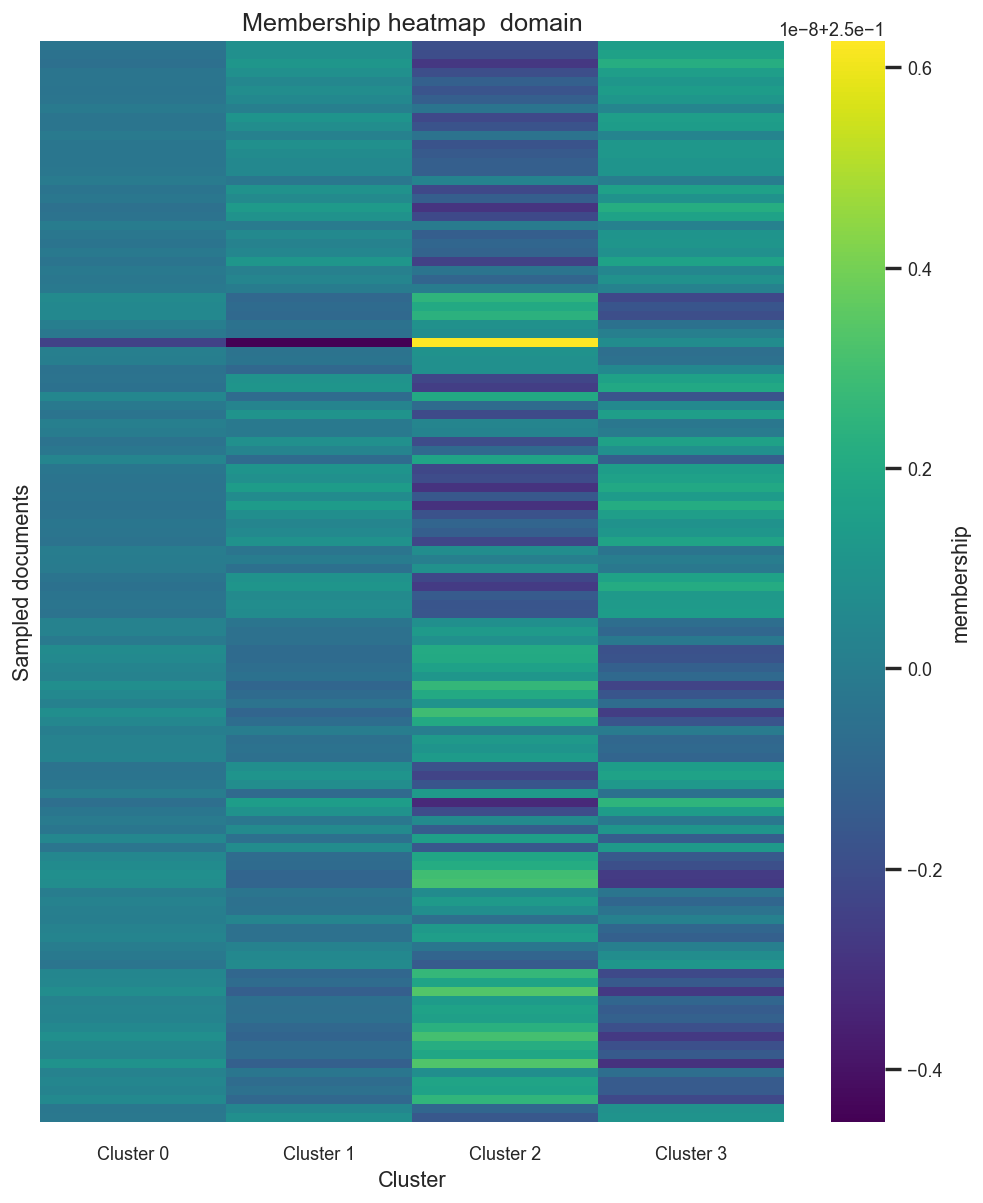

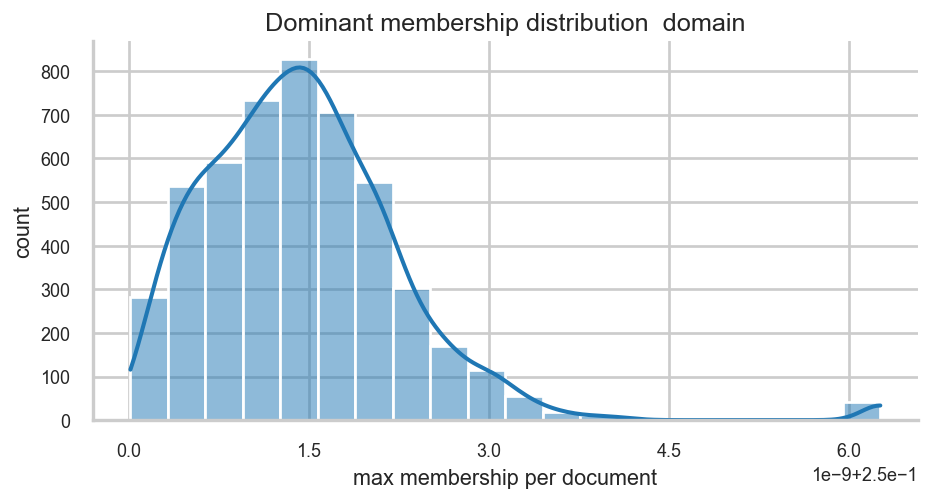

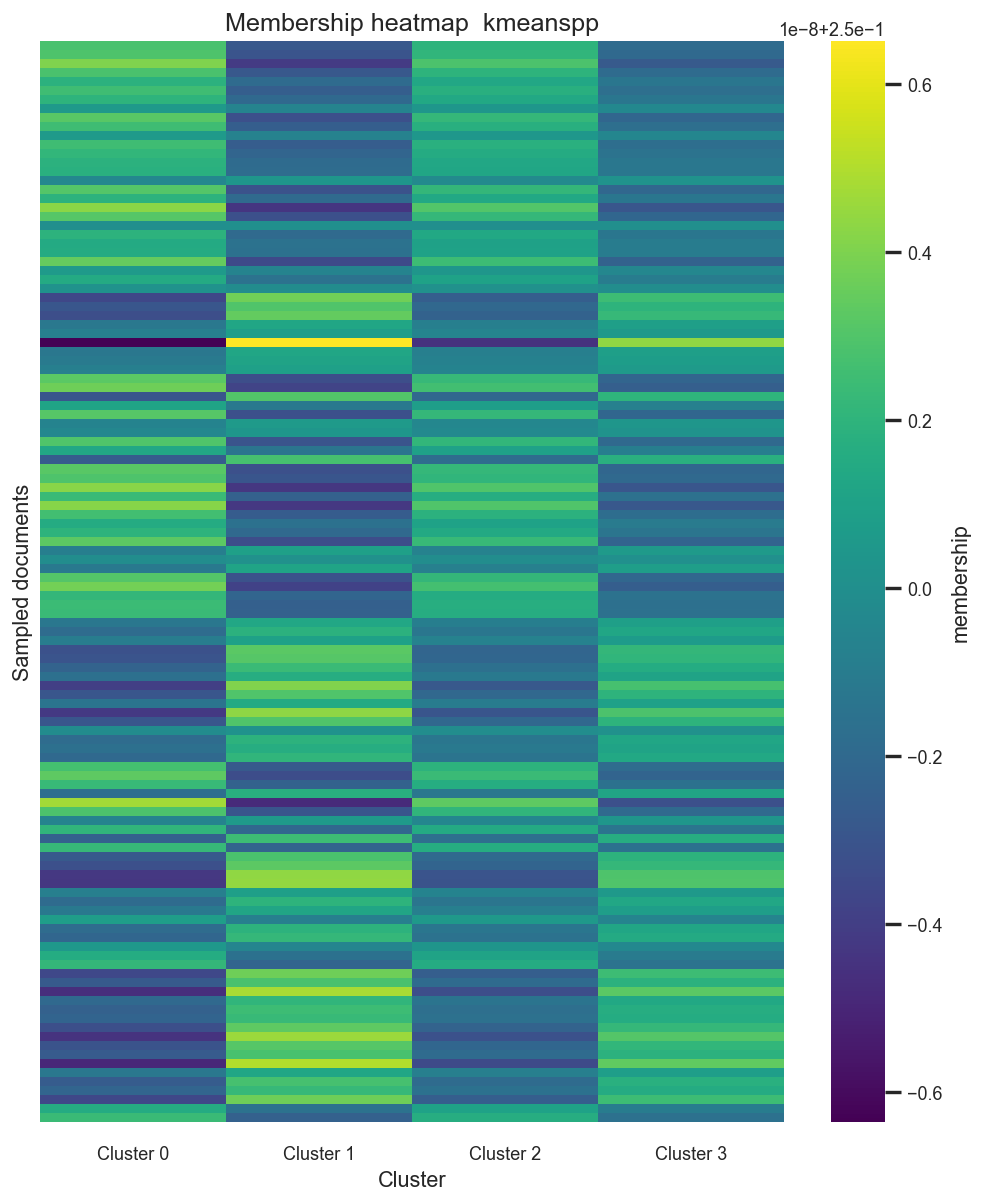

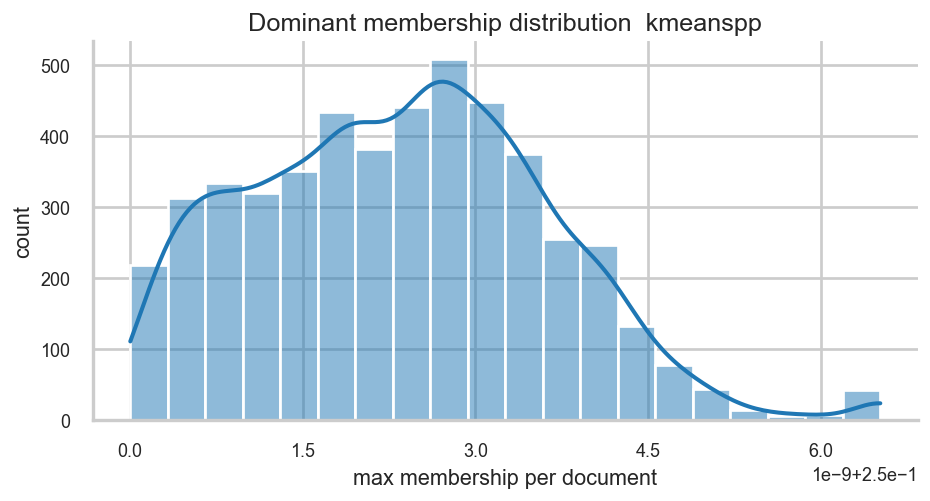

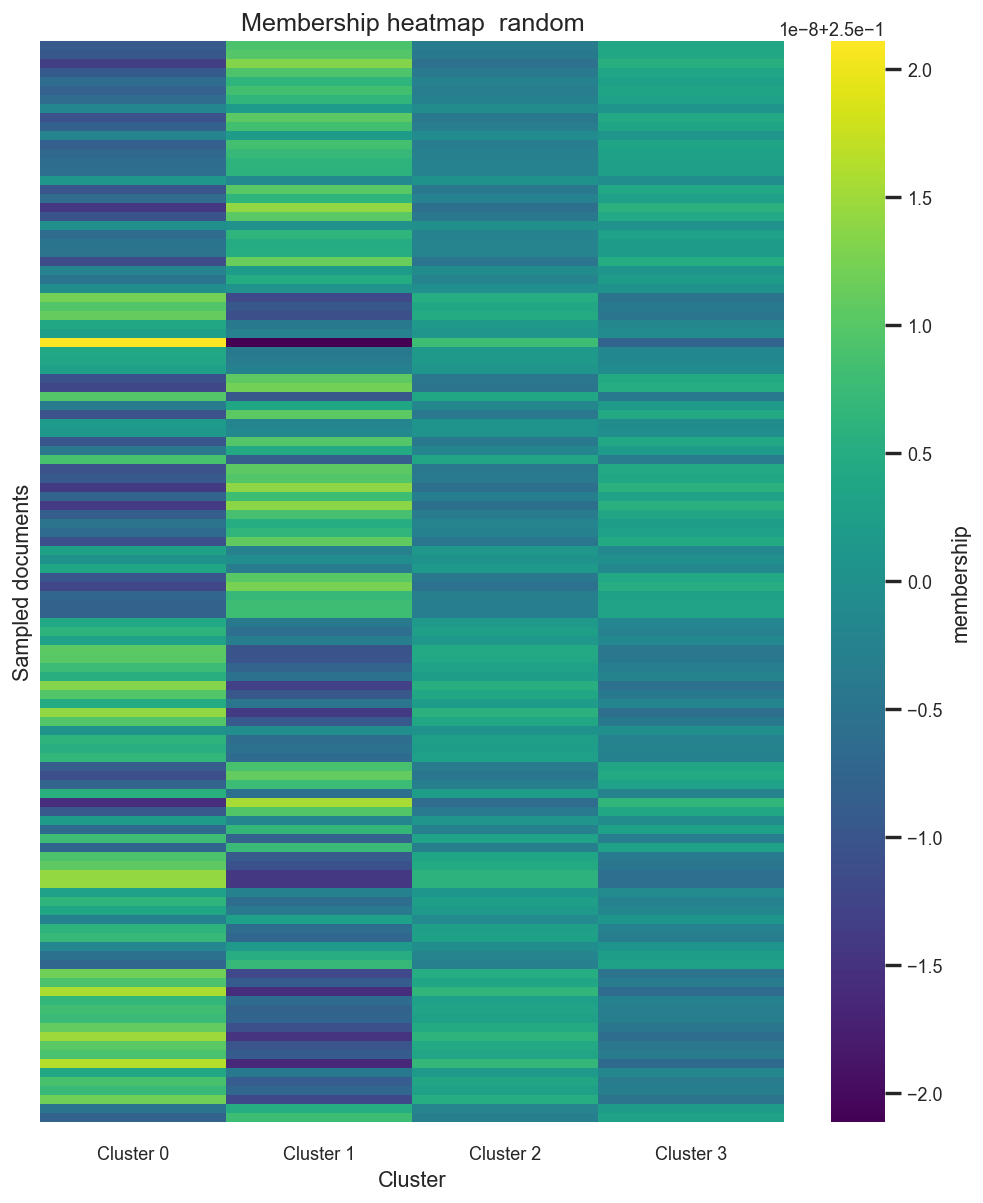

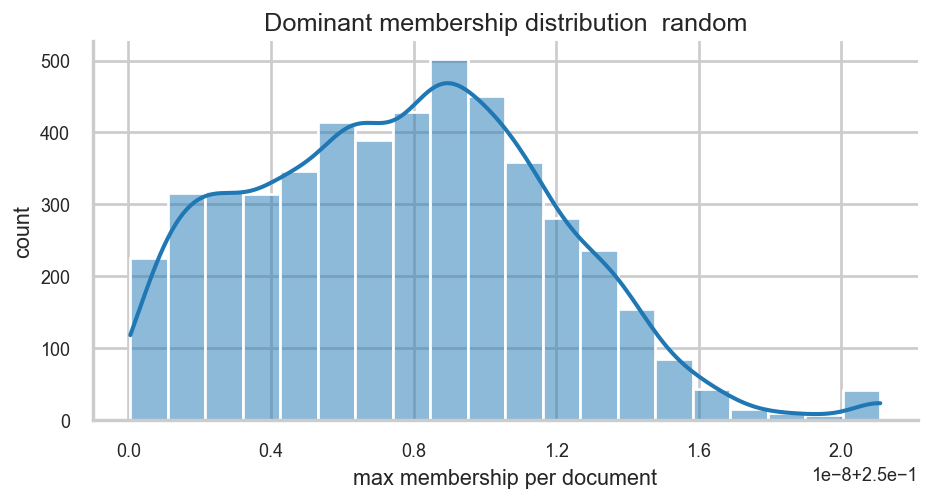

In [24]:

# 2) Visual diagnostics per strategy (heatmap + histogram)
for name, payload in analysis.items():
    U = payload["U"]
    plot_membership_heatmap(U, strategy=name)
    plot_membership_hist(U, strategy=name)


In [25]:

# 3) Cohort comparison against domain labels (purity + ARI + confusion matrix)
cohort_rows = []
for name, payload in analysis.items():
    result = compare_with_domain_labels(payload["U"], DOMAIN_LABELS)
    cohort_rows.append({
        "strategy": name,
        "purity": result["purity"],
        "adjusted_rand_index": result["ari"],
    })
    print(f"Confusion matrix  {name}")
    display(result["confusion"])

cohort_df = pd.DataFrame(cohort_rows).set_index("strategy").sort_values("purity", ascending=False)
display(cohort_df)


Confusion matrix  domain


,cluster_0,cluster_1,cluster_2,cluster_3
domain_0,2,23,618,593
domain_1,2,14,631,589
domain_2,4,11,640,581
domain_3,1,18,619,597


Confusion matrix  kmeanspp


,cluster_0,cluster_1,cluster_2,cluster_3
domain_0,604,632,0,0
domain_1,592,644,0,0
domain_2,579,656,0,1
domain_3,594,640,0,1


Confusion matrix  random


,cluster_0,cluster_1,cluster_2,cluster_3
domain_0,631,603,0,2
domain_1,643,592,0,1
domain_2,656,579,0,1
domain_3,640,595,0,0


,purity,adjusted_rand_index
strategy,,
kmeanspp,0.520332,-0.000202
random,0.519927,-0.000202
domain,0.507384,-0.000225


In [26]:

# 4) Representative documents (highest soft membership per cluster)
all_top_docs = []
for name, payload in analysis.items():
    top_df = top_documents_by_cluster(payload["U"], top_k=5)
    top_df.insert(0, "strategy", name)
    all_top_docs.append(top_df)

top_docs_df = pd.concat(all_top_docs, ignore_index=True)
display(top_docs_df)


,strategy,cluster,rank,document_id,membership
0,domain,0,1,2975,0.25
1,domain,0,2,4384,0.25
2,domain,0,3,1430,0.25
3,domain,0,4,3761,0.25
4,domain,0,5,1290,0.25
5,domain,1,1,1168,0.25
6,domain,1,2,3014,0.25
7,domain,1,3,1212,0.25
8,domain,1,4,4909,0.25
9,domain,1,5,345,0.25


In [27]:
# 5) Centroid feature signatures (which TF-IDF dimensions dominate each cluster)
all_feature_tables = []
for name, payload in analysis.items():
    feat_df = top_features_from_centroids(payload["centroids"], top_k=8)
    feat_df.insert(0, "strategy", name)
    all_feature_tables.append(feat_df)

feature_df = pd.concat(all_feature_tables, ignore_index=True)
display(feature_df)


,strategy,cluster,rank,feature,weight
0,domain,0,1,the_patient,0.061082
1,domain,0,2,this,0.049244
2,domain,0,3,which,0.049235
3,domain,0,4,who,0.040189
4,domain,0,5,the_procedure,0.035250
...,...,...,...,...,...
91,random,3,4,who,0.040189
92,random,3,5,the_procedure,0.035250
93,random,3,6,that,0.033457
94,random,3,7,the_operating_room,0.031381



### Next steps for Milestone 2

- When the MPI implementation lands, store per-rank diagnostics (timings, load stats) next to these CSVs so the same notebook can correlate communication costs with cluster quality.


### Why current outputs look uniform
- The real `features.csv` is a 4,943 × 500 TF-IDF matrix where each document activates only a handful of terms, so pairwise Euclidean distances between documents and centroids are nearly identical. With fuzziness $m=2$, the FCM update $$u_{ij} = \left(\sum_k \left(\frac{d(x_i,c_j)}{d(x_i,c_k)}\right)^{2/(m-1)}\right)^{-1}$$ collapses to ≈$1/C$, yielding memberships like 0.24999999 across all clusters. In contrast, the dummy generator deliberately amplified disjoint feature bands per clinical group, so centroids were far apart and memberships concentrated near 1.0 for a single cluster.
- Because the collected distances barely differ, centroid updates also converge to almost identical vectors, so the CSVs appear constant even though all calculations are correct. This is a data-geometry issue, not a bug in the FCM code or Member 4 analysis.

### What would improve separation (future data/algorithm work)
1. **Increase distance contrast**: Normalize or rescale columns, remove ultra-sparse terms, or switch to cosine distance so documents with similar directions but different magnitudes separate meaningfully.
2. **Dimensionality reduction**: Apply PCA/UMAP or feature selection to highlight discriminative concepts before running FCM.
3. **Tune fuzziness (`FCM_M`) and cluster count**: Lowering `m` toward 1.5 forces harder memberships; matching the number of clusters to the true cohort count avoids diluting weak signals.
4. **Use domain-guided seeding**: Real ICD-based labels (once available) can initialize centroids away from each other and break symmetry sooner.
Documenting these constraints keeps the deliverable transparent: uniform memberships stem from the current feature matrix, and the remediation steps fall outside Member 4’s visualization responsibilities.